# Quickstart

`Pyrosm` reads [OpenStreetMap](https://www.openstreetmap.org/) data from `.osm.pbf` files into [GeoPandas](https://geopandas.org/) GeoDataFrames. Because it reads from local PBF dumps (rather than an online API), it is fast enough to parse data for whole cities or countries.

This page is a five-minute tour; the other guides go deeper into each topic.

**How to?**

- [Get OSM data](#get-osm-data)
- [Read a street network](#read-a-street-network)
- [Read buildings and POIs](#read-buildings-and-pois)
- [Export a network to a graph](#export-a-network-to-a-graph)
- [Crop a PBF to a smaller file](#crop-a-pbf-to-a-smaller-file)
- [Where to next](#where-to-next)

## Get OSM data

`pyrosm` ships a small test dataset and can download data for hundreds of regions with `get_data()`. Here we use the bundled test file:

In [1]:
from pyrosm import OSM, get_data

# A small bundled extract (or e.g. get_data("Helsinki") to download a city)
fp = get_data("test_pbf")
fp

'/Users/tenkanh2/Library/CloudStorage/OneDrive-AaltoUniversity/Documents/codes/uni/pyrosm/pyrosm/data/test.osm.pbf'

In [ ]:
from pyrosm import geocode, get_data_by_bbox, get_data


geom = geocode(query="Copenhagen")
pbf_fp = get_data_by_bbox(geom)
cropped = OSM(pbf_fp, bounding_box=geom).to_pbf()
pbf_fp


Geocoded 'Copenhagen' to: København, Københavns Kommune, Region Hovedstaden, 1357, Danmark
Suggested Geofabrik extract for the bounding box: 'Denmark' (id: denmark)


'https://download.geofabrik.de/europe/denmark-latest.osm.pbf'

In [2]:
from pyrosm import get_data_by_geocoding

fp = get_data_by_geocoding("Brighton and Hove, UK")

Geocoded 'Brighton and Hove, UK' to: Brighton and Hove, England, United Kingdom
Suggested Geofabrik extract for the bounding box: 'England' (id: england)
Downloaded Protobuf data 'england-latest.osm.pbf' (1586.35 MB) to:
'/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/england-latest.osm.pbf'


In [ ]:
from pyrosm import get_data_by_bbox

#fp = get_data_by_bbox()

TypeError: get_data_by_bbox() missing 1 required positional argument: 'bbox'

You can also fetch data straight from a **place name** — this geocodes the place and downloads the Geofabrik extract that covers it:

```python
from pyrosm import get_data_by_geocoding

fp = get_data_by_geocoding("Brighton and Hove, UK")
```

See [Downloading OSM data](downloading_data.ipynb) for downloading by name, bounding box or place name.

## Read a street network

Initialise the `OSM` reader with a file path, then read a network for a given travel mode:

In [2]:
%matplotlib inline
osm = OSM(fp)
drive = osm.get_network("driving")
drive.head(3)

,access,bridge,highway,int_ref,lanes,lit,maxspeed,name,oneway,ref,service,surface,id,timestamp,version,tags,osm_type,geometry,length
0,NaN,NaN,secondary,NaN,2,NaN,80,Hurukselantie,NaN,357,NaN,asphalt,4732994,1441800394,23,"{""visible"":false,""name:fi"":""Hurukselantie""}",way,"MULTILINESTRING ((26.9431 60.5258, 26.94295 60...",1504.0
1,NaN,NaN,secondary,NaN,NaN,NaN,NaN,NaN,yes,170,NaN,NaN,5184588,1378828296,7,"{""visible"":false}",way,"MULTILINESTRING ((26.94778 60.52231, 26.94717 ...",242.0
2,NaN,yes,secondary,NaN,NaN,NaN,NaN,NaN,yes,170,NaN,NaN,5184589,1378828298,2,"{""visible"":false,""layer"":""1""}",way,"MULTILINESTRING ((26.94891 60.52181, 26.94778 ...",83.0


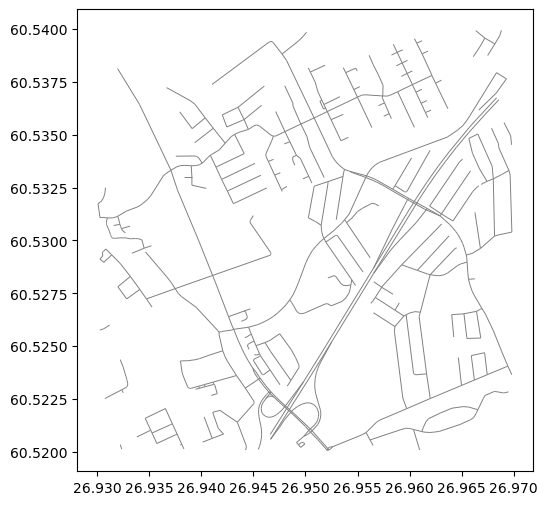

In [3]:
ax = drive.plot(figsize=(6, 6), color="gray", linewidth=0.7)

## Read buildings and POIs

The same reader extracts other datasets — buildings, Points of Interest, landuse, natural elements and boundaries:

buildings: 2208 | POIs: 23


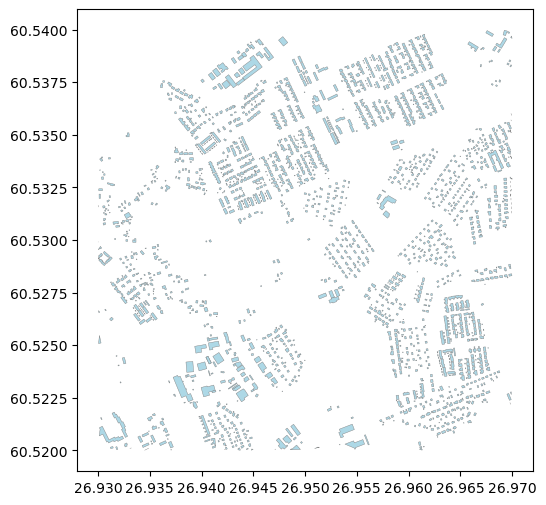

In [4]:
buildings = osm.get_buildings()
pois = osm.get_pois()
print("buildings:", len(buildings), "| POIs:", len(pois))
ax = buildings.plot(figsize=(6, 6), color="lightblue", edgecolor="gray", linewidth=0.3)

## Export a network to a graph

Street networks can be exported as a directed graph for `networkx`, `igraph` or `pandarm`:

In [5]:
nodes, edges = osm.get_network(nodes=True)
G = OSM.to_graph(nodes, edges, graph_type="networkx")
type(G)

networkx.classes.multidigraph.MultiDiGraph

## Crop a PBF to a smaller file

You can write a smaller `.osm.pbf` that covers only a bounding box — handy before sharing a file or re-reading a sub-area:

In [6]:
import os
from pyrosm import get_data

minx, miny, maxx, maxy = buildings.total_bounds
# Keep roughly the south-west quarter and write it to a new PBF
bbox = [minx, miny, (minx + maxx) / 2, (miny + maxy) / 2]
cropped = OSM(fp, bounding_box=bbox).to_pbf()
print("wrote", os.path.basename(cropped), os.path.getsize(cropped), "bytes")

wrote pyrosm_crop_j75w4emb.osm.pbf 39336 bytes


## Where to next

- [Downloading OSM data](downloading_data.ipynb) — by name, bounding box or place name
- [Reading OSM datasets](reading_osm_data.ipynb) — networks, buildings, POIs, landuse, natural, boundaries, history
- [Parsing OSM data with custom queries](custom_filter.ipynb)
- [Tags and columns](tags_and_columns.ipynb) — control columns and memory
- [Saving and cropping data](saving_and_cropping.ipynb) — `to_pbf` and `write_pbf`
- [Working with graphs](graphs.ipynb) — export networks and analyse them